# Metaheuristic Algorithm Benchmark Comparison
### WOA vs PSO vs GA vs DE

This notebook compares four algorithms on standard optimization benchmarks:

- **WOA** — Whale Optimization Algorithm  
- **PSO** — Particle Swarm Optimization  
- **GA** — Genetic Algorithm  
- **DE** — Differential Evolution  

Benchmarks analyzed:
- Sphere  
- Rastrigin  
- Ackley  

Each algorithm’s:
- Convergence curve  
- Best fitness value  
- Statistical performance (mean, std over multiple runs)  

are visualized and compared.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random


## Benchmark Functions
These are standard in optimization research.

In [2]:
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    return 10 * len(x) + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def ackley(x):
    a = 20
    b = 0.2
    c = 2 * np.pi
    n = len(x)

    return -a * np.exp(-b * np.sqrt(np.sum(x**2) / n)) \
           - np.exp(np.sum(np.cos(c * x)) / n) \
           + a + np.e

## Imported Optimization Algorithms

To keep this notebook more clean and modular, all algorithm implementations are stored in external Python files.

### Whale Optimization Algorithm (WOA)
Imported from:
- 'WOA.py'

This file contains the full WOA implementation used in both notebooks.

### Benchmark Algorithms (PSO, GA, DE)
Stored inside the `/benchmarks` folder:

- `benchmarks/PSO.py`
- `benchmarks/GA.py`
- `benchmarks/DE.py`

These files contain implementations of:
- Particle Swarm Optimization (PSO)
- Genetic Algorithm (GA)
- Differential Evolution (DE)

This notebook imports these implementations and uses them for visual and numerical benchmark comparisons against WOA.




In [4]:
from WOA import WOA
from benchmarks.PSO import PSO
from benchmarks.GA import GA
from benchmarks.DE import DE

## Run All Algorithms on Sphere, Rastrigin, and Ackley

This section runs WOA, PSO, GA, and DE on all three benchmark functions:

- **Sphere**
- **Rastrigin**
- **Ackley**

For each benchmark:
- All four algorithms are executed
- Best fitness values are collected
- Convergence curves are plotted in a combined dashboard

In [10]:
# List of benchmark functions
benchmarks = {
    "Sphere": sphere,
    "Rastrigin": rastrigin,
    "Ackley": ackley
}

results = {}   # to store final fitness and curves

dim = 30
lb, ub = -100, 100

for name, func in benchmarks.items():
    print(f"\nRunning algorithms on: {name} Function")

    woa_best, woa_curve = WOA(func, dim, lb, ub)
    pso_best, pso_curve = PSO(func, dim, lb, ub)
    ga_best, ga_curve = GA(func, dim, lb, ub)
    de_best, de_curve = DE(func, dim, lb, ub)

    results[name] = {
        "WOA": (woa_best, woa_curve),
        "PSO": (pso_best, pso_curve),
        "GA":  (ga_best, ga_curve),
        "DE":  (de_best, de_curve)
    }

    print(f"  WOA: {func(woa_best)}")
    print(f"  PSO: {func(pso_best)}")
    print(f"  GA: {func(ga_best)}")
    print(f"  DE: {func(de_best)}")



Running algorithms on: Sphere Function
  WOA: 1.0084358617684526e-82
  PSO: 2159.3400758000025
  GA: 2895.5389312463494
  DE: 0.0015687708897191574

Running algorithms on: Rastrigin Function
  WOA: 0.0
  PSO: 6866.0085433947415
  GA: 6415.879767580082
  DE: 346.32187895549265

Running algorithms on: Ackley Function
  WOA: 4.440892098500626e-16
  PSO: 19.999999942744154
  GA: 19.686283096289948
  DE: 19.999999835976226


## Dashboard of Convergence Plots

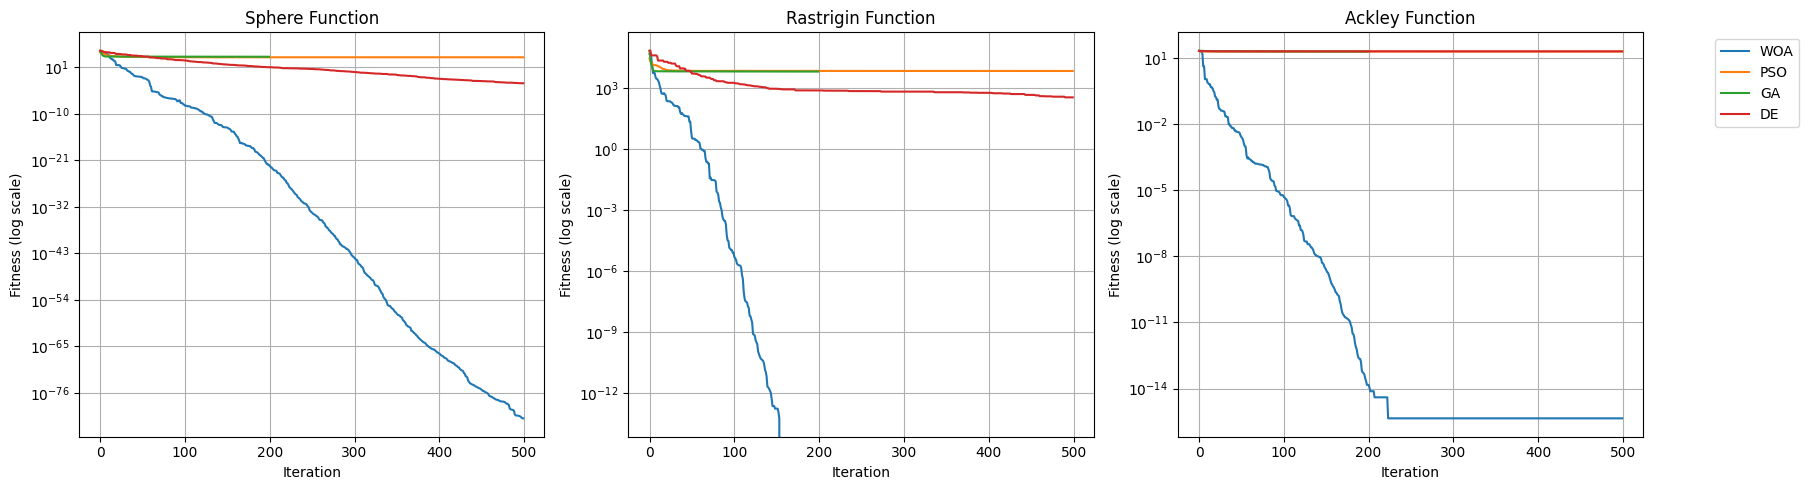

In [11]:
plt.figure(figsize=(18, 5))

for idx, (name, func) in enumerate(benchmarks.items()):
    plt.subplot(1, 3, idx + 1)

    woa_curve = results[name]["WOA"][1]
    pso_curve = results[name]["PSO"][1]
    ga_curve  = results[name]["GA"][1]
    de_curve  = results[name]["DE"][1]

    plt.plot(woa_curve, label='WOA')
    plt.plot(pso_curve, label='PSO')
    plt.plot(ga_curve, label='GA')
    plt.plot(de_curve, label='DE')

    plt.yscale('log')
    plt.title(f'{name} Function')
    plt.xlabel('Iteration')
    plt.ylabel('Fitness (log scale)')
    plt.grid(True)

plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.show()